In [1]:
!pip3 install pandas
!pip3 install seaborn
!pip3 install numpy
!pip3 install scikit-learn

In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [3]:
data = pd.read_csv('images.csv', sep=',')

In [4]:
data.groupby('label', as_index=False) \
    .agg({'pixel0': 'count'}) \
    .rename(columns={'pixel0': 'count'})

,label,count
0,0,4132
1,1,4684
2,2,4177
3,3,4351
4,4,4072
5,5,3795
6,6,4137
7,7,4401
8,8,4063
9,9,4188


In [5]:
sns.set(rc={'figure.figsize': (11.7, 8.27)})

In [6]:
from sklearn.model_selection import train_test_split

X = data.drop(columns=['label'])
y = data['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

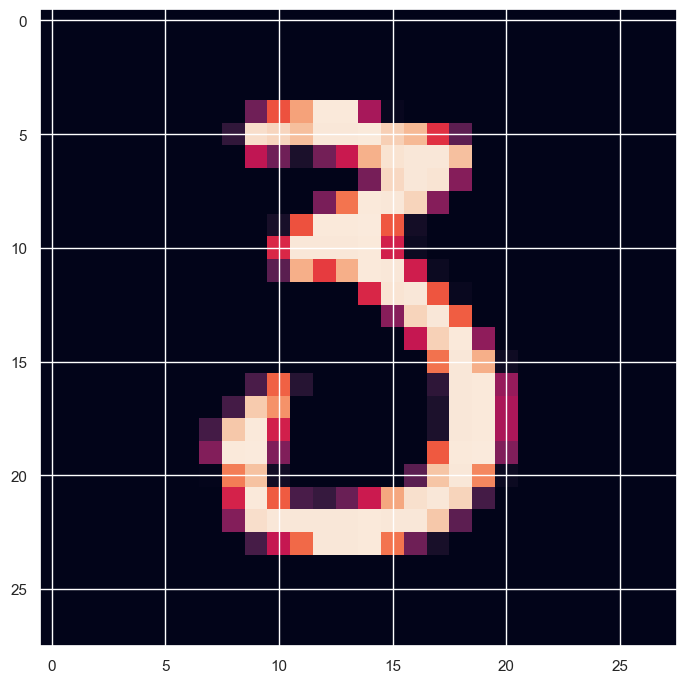

In [19]:
item_to_show = 8
X_numpy = X_train.iloc[item_to_show].values
image = X_numpy.reshape(28, 28).astype('uint8')
plt.imshow(image)

In [13]:
from scipy.signal import convolve2d

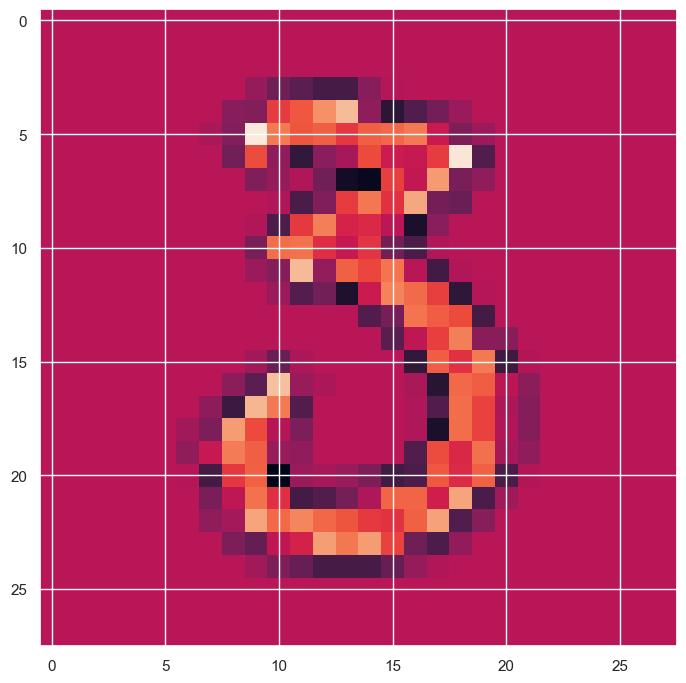

In [20]:
kernel = np.array([[0, -1, 0], [-1, 4, -1], [0, -1, 0]])
image_convolved = convolve2d(image, kernel, mode='same')
plt.imshow(image_convolved)

In [54]:
X_y_train = X_train.copy(deep=True)
X_y_train['y'] = y_train

<Axes: >

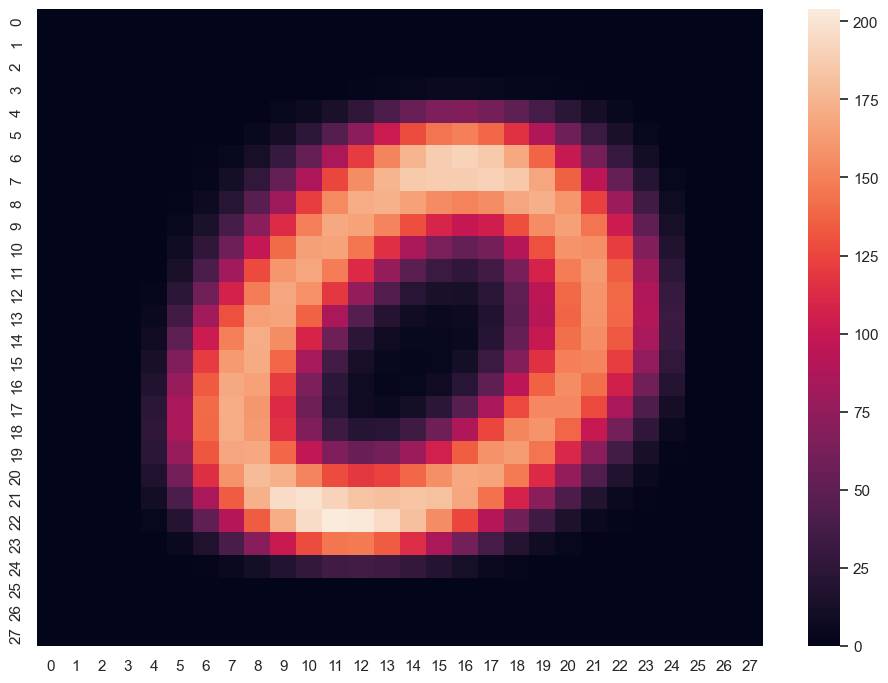

In [55]:
number_to_show = 0
X_number = X_y_train[X_y_train['y'] == number_to_show].drop(columns=['y'])
sns.heatmap(pd.DataFrame(X_number.mean().values.reshape(28, 28)))

<Axes: >

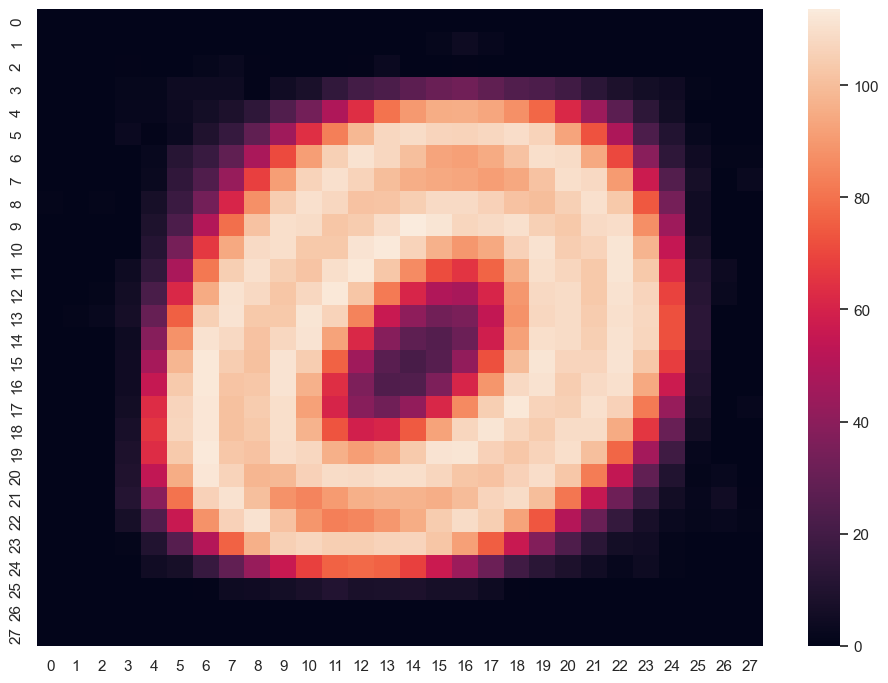

In [57]:
desc_number = X_number.describe()
sns.heatmap(pd.DataFrame(desc_number.loc['std'].values.reshape(28, 28)))
